In [ ]:
import sys
import csv
import random
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt
import yaml

PROJECT_ROOT = Path(r"E:\project\SibDor")
DATASET_DIR  = PROJECT_ROOT / "02_yolo_dataset_horizontal"
DATA_YAML    = DATASET_DIR  / "data.yaml"
MODELS_DIR   = PROJECT_ROOT / "03_models"
REPORTS_DIR  = PROJECT_ROOT / "06_reports"

print(f"Python:  {sys.version}")
print(f"Датасет: {DATASET_DIR}")

# Читаем data.yaml
with open(DATA_YAML, "r", encoding="utf-8") as f:
    data_cfg = yaml.safe_load(f)

num_classes = len(data_cfg["names"])
print(f"Классов: {num_classes}")
print(f"Классы:  {data_cfg['names']}")

Python:  3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]
Датасет: E:\project\SibDor\02_yolo_dataset_horizontal
Классов: 26
Классы:  {0: '1.12', 1: '1.13', 2: '1.14.1', 3: '1.14.2', 4: '1.14.3', 5: '1.15', 6: '1.16.1', 7: '1.16.2', 8: '1.16.3', 9: '1.17.1', 10: '1.17.2', 11: '1.18', 12: '1.19', 13: '1.20', 14: '1.22', 15: '1.23.1', 16: '1.23.2', 17: '1.23.3', 18: '1.24.1', 19: '1.24.2', 20: '1.24.3', 21: '1.24.4', 22: '1.25', 23: '1.26', 24: 'ШП', 25: '1.21'}


In [2]:
for split in ["train", "val", "test"]:
    imgs = list((DATASET_DIR / "images" / split).glob("*.*"))
    lbls = list((DATASET_DIR / "labels" / split).glob("*.txt"))
    status = "✅" if len(imgs) == len(lbls) and len(imgs) > 0 else "❌"
    print(f"  {split}: {len(imgs)} images, {len(lbls)} labels {status}")

# Подсчёт объектов по классам в train
from collections import Counter
train_class_counts = Counter()
for label_file in (DATASET_DIR / "labels" / "train").glob("*.txt"):
    for line in label_file.read_text(encoding="utf-8").splitlines():
        line = line.strip()
        if line:
            train_class_counts[int(line.split()[0])] += 1

print(f"\nОбъектов в train по классам:")
for cid in sorted(train_class_counts):
    name = data_cfg["names"].get(cid, f"id{cid}")
    cnt = train_class_counts[cid]
    bar = "█" * min(cnt, 40)
    print(f"  [{cid:>2}] {name:<10} {cnt:>4} {bar}")


  train: 517 images, 517 labels ✅
  val: 40 images, 40 labels ✅
  test: 36 images, 36 labels ✅

Объектов в train по классам:
  [ 0] 1.12         80 ████████████████████████████████████████
  [ 1] 1.13         54 ████████████████████████████████████████
  [ 2] 1.14.1      187 ████████████████████████████████████████
  [ 6] 1.16.1       92 ████████████████████████████████████████
  [ 7] 1.16.2       66 ████████████████████████████████████████
  [ 8] 1.16.3       48 ████████████████████████████████████████
  [ 9] 1.17.1       80 ████████████████████████████████████████
  [11] 1.18        193 ████████████████████████████████████████
  [12] 1.19         78 ████████████████████████████████████████
  [13] 1.20         18 ██████████████████
  [15] 1.23.1       80 ████████████████████████████████████████
  [16] 1.23.2       30 ██████████████████████████████
  [17] 1.23.3       18 ██████████████████
  [18] 1.24.1       85 ████████████████████████████████████████
  [19] 1.24.2       80 ██████████

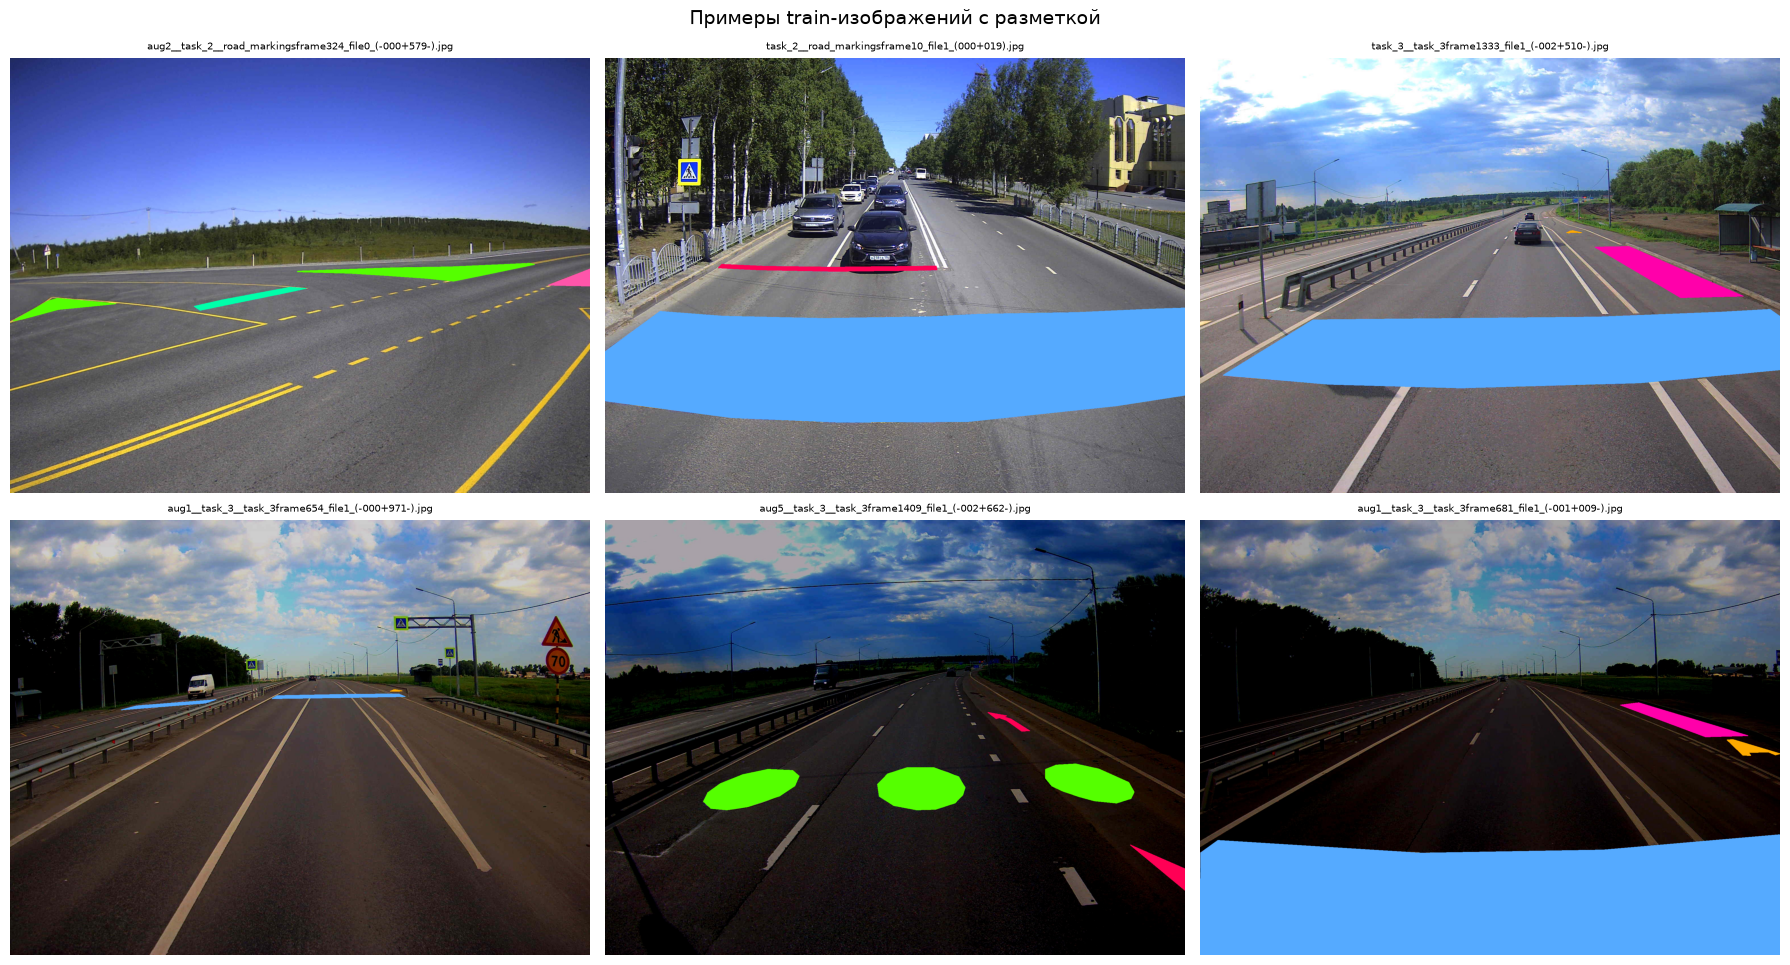

In [3]:
COLORS = [
    (255, 0, 85), (0, 255, 170), (85, 170, 255), (255, 170, 0),
    (170, 0, 255), (0, 255, 85), (255, 85, 170), (85, 255, 0),
    (170, 255, 85), (255, 0, 170), (0, 85, 255), (85, 0, 255),
]

train_imgs = sorted((DATASET_DIR / "images" / "train").glob("*.*"))
sample_imgs = random.sample(train_imgs, min(6, len(train_imgs)))

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, img_path in zip(axes.flat, sample_imgs):
    img_arr = np.fromfile(str(img_path), dtype=np.uint8)
    img = cv2.imdecode(img_arr, cv2.IMREAD_COLOR)
    if img is None:
        ax.set_title(f"⚠️ {img_path.name}", fontsize=8)
        ax.axis("off")
        continue
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    label_path = DATASET_DIR / "labels" / "train" / f"{img_path.stem}.txt"
    if label_path.exists():
        for line in label_path.read_text(encoding="utf-8").splitlines():
            parts = line.strip().split()
            if len(parts) < 6:
                continue
            cls_id = int(parts[0])
            coords = [float(x) for x in parts[1:]]
            pts = np.array([(coords[i]*w, coords[i+1]*h) for i in range(0, len(coords), 2)], dtype=np.int32)
            color = COLORS[cls_id % len(COLORS)]
            cv2.fillPoly(img, [pts], color=(*color, 80))
            cv2.polylines(img, [pts], True, color, 2)

    ax.imshow(img)
    ax.set_title(img_path.name, fontsize=7)
    ax.axis("off")

plt.suptitle("Примеры train-изображений с разметкой", fontsize=14)
plt.tight_layout()
plt.savefig(str(REPORTS_DIR / "train_samples_preview.png"), dpi=150)
plt.show()


In [4]:
from ultralytics import YOLO

# ========= НАСТРОЙКИ — МЕНЯТЬ ТУТ =========

MODEL_NAME    = "yolov8n-seg"                       # архитектура (n=nano, s=small, m=medium)
PRETRAINED    = str(MODELS_DIR / "yolov8n-seg.pt")  # pretrained веса
RUN_NAME      = "yolov8n_seg_horizontal_v3"         # имя эксперимента (папка в 03_models/)

TRAIN_CONFIG = dict(
    data=str(DATA_YAML),

    # --- Основные ---
    epochs=50,
    imgsz=1280,             # 1280 — мелкие стрелки видны лучше
    batch=2,                # уменьшено из-за imgsz=1280
    patience=30,            # early stopping
    workers=2,              # на Windows иногда нужно 0

    # --- Устройство ---
    device="cpu",           # Ultralytics не поддерживает DirectML

    # --- Аугментации ---
    hsv_h=0.015,
    hsv_s=0.5,
    hsv_v=0.3,
    degrees=5.0,
    translate=0.1,
    scale=0.3,
    flipud=0.0,             # НЕ вверх-вниз (дорога всегда снизу!)
    fliplr=0.5,
    mosaic=1.0,
    mixup=0.1,
    copy_paste=0.1,

    # --- Оптимизатор ---
    optimizer="AdamW",
    lr0=0.001,
    lrf=0.01,
    weight_decay=0.0005,
    warmup_epochs=5,

    # --- Сохранение ---
    project=str(MODELS_DIR),
    name=RUN_NAME,
    save=True,
    save_period=25,
    plots=True,
    verbose=True,
    exist_ok=True,
)

# ========= КОНЕЦ НАСТРОЕК =========

model = YOLO(PRETRAINED)
print(f"Модель:     {MODEL_NAME}")
print(f"Параметров: {sum(p.numel() for p in model.model.parameters()) / 1e6:.1f}M")
print(f"Эксперимент: {RUN_NAME}")
print(f"\nКонфигурация:")
for k, v in TRAIN_CONFIG.items():
    print(f"  {k}: {v}")

Модель:     yolov8n-seg
Параметров: 3.4M
Эксперимент: yolov8n_seg_horizontal_v3

Конфигурация:
  data: E:\project\SibDor\02_yolo_dataset_horizontal\data.yaml
  epochs: 50
  imgsz: 1280
  batch: 2
  patience: 30
  workers: 2
  device: cpu
  hsv_h: 0.015
  hsv_s: 0.5
  hsv_v: 0.3
  degrees: 5.0
  translate: 0.1
  scale: 0.3
  flipud: 0.0
  fliplr: 0.5
  mosaic: 1.0
  mixup: 0.1
  copy_paste: 0.1
  optimizer: AdamW
  lr0: 0.001
  lrf: 0.01
  weight_decay: 0.0005
  warmup_epochs: 5
  project: E:\project\SibDor\03_models
  name: yolov8n_seg_horizontal_v3
  save: True
  save_period: 25
  plots: True
  verbose: True
  exist_ok: True


In [5]:
#
# На CPU (imgsz=1280, batch=4, 100 эпох) — ожидай **~3-8 часов**.
#
# Если OOM → уменьши `batch` до 2 или `imgsz` до 640.

results = model.train(**TRAIN_CONFIG)
print("\n✅ Обучение завершено!")

# Путь к результатам
RUN_DIR = MODELS_DIR / RUN_NAME
print(f"Результаты: {RUN_DIR}")


New https://pypi.org/project/ultralytics/8.4.104 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.98  Python-3.11.9 torch-2.4.1+cpu CPU (AMD Ryzen 5 5600H with Radeon Graphics)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=2, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.1, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=E:\project\SibDor\02_yolo_dataset_horizontal\data.yaml, degrees=5.0, deterministic=True, device=cpu, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.5, hsv_v=0.3, imgsz=1280, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=E:\pro

KeyboardInterrupt: 